In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader

import os
import matplotlib.pyplot as plt
import numpy as np
import imageio
import copy
import math
from tqdm.notebook import trange, tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [43]:
batch_size = 256
lr = 1e-4
epochs = 400
img_size = 32

data_set_root = "../../datasets"

In [3]:
transform = transforms.Compose(
    [
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=([0.5, 0.5, 0.5]), std=([0.5, 0.5, 0.5])),
    ]
)

train_dataset = datasets.CIFAR10(
    data_set_root, train=True, download=True, transform=transform
)

num_workers = os.cpu_count()

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)

100%|██████████| 170M/170M [00:02<00:00, 75.4MB/s]


Cosine noise scheduler

$
\bar{\alpha}_t = \frac{\cos\Bigl(\frac{t+s}{1+s}\cdot\frac{\pi}{2}\Bigr)^2}{\cos\Bigl(\frac{s}{1+s}\cdot\frac{\pi}{2}\Bigr)^2}
$

$\bar{\alpha}_t$ is the fraction of the original signal remaining after $t$ diffusion steps

$
\beta_t = \min\Bigl(1 - \frac{\bar{\alpha}{t+1}}{\bar{\alpha}{t}}, \; 0.999\Bigr)
$

$\beta_t$ represent the noise variance added at each diffusion timestep. They control how much noise is injected into the image during the forward process,
Each $\beta_t$ determines the variance of the Gaussian noise added at timestep $t$. A higher $\beta_t$ means more noise is injected at that particular step.

$
\alpha_t = 1 - \beta_t
$



---



Forward Diffusion Process -

Given an image $x$ and time step $t$, the function returns a noisy version:

$
x_t = \sqrt{\bar{\alpha}_t}\, x + \sqrt{1-\bar{\alpha}_t}\, \epsilon
$


In [4]:
class DiffusionModel(nn.Module):
    def __init__(self, network, timesteps, device=None):
        super().__init__()
        self.timesteps = timesteps
        self.device = device
        self.network = network.to(device)

        self.betas, self.alphas, self.alphas_bar = self.cosine_alphas_bar(
            self.timesteps
        )

        self.betas, self.alphas, self.alphas_bar = (
            self.betas.to(self.device),
            self.alphas.to(self.device),
            self.alphas_bar.to(self.device),
        )

    # Cosine noise scheduling
    def cosine_alphas_bar(self, timesteps, s=0.008):
        # s slightly shifts the schedule which controls the curvature of the noise schedule

        steps = timesteps + 1
        t = torch.linspace(0, 1, steps)

        # Compute the cosine cumulative product (alpha_bar) values
        alphas_bar = torch.cos((t + s) / (1 + s) * (math.pi / 2)) ** 2
        alphas_bar = alphas_bar / alphas_bar[0]  # Normalize so that alphas_bar[0] = 1

        # Compute betas from the ratio of consecutive alpha_bar values
        betas = []
        for i in range(timesteps):
            beta = 1 - alphas_bar[i + 1] / alphas_bar[i]
            beta = min(beta, 0.999)  # clip for numerical stability
            betas.append(beta)

        betas = torch.tensor(betas, dtype=torch.float32)
        alphas = 1 - betas

        return betas, alphas, alphas_bar[:-1]  # Exclude the final element which is 0

    def forward(self, x, t, latent_noise=None):
        # x shape: (batch_size, channels=3, image_size, image_size)
        # t: (batch_size)

        # Make the input image more noisy (Forward process of diffusion)
        a_bar = (
            self.alphas_bar[t].unsqueeze(dim=-1).unsqueeze(dim=-1).unsqueeze(dim=-1)
        )  # (batch_size) -> (batch_size, 1, 1, 1)

        if latent_noise is None:
            # sample of random gaussian noise
            latent_noise = torch.randn_like(x).to(self.device)

        noisy = a_bar.sqrt() * x + (1 - a_bar).sqrt() * latent_noise
        return noisy  # (batch_size, channels=3, image_size, image_size)

    def backward(self, x, t):
        # Backward process of diffusion
        # Run each image through the network for each timestep t
        return self.network(x, t)

In [5]:
def positional_encoding(max_length, d_model):
    pe = torch.zeros(max_length, d_model)  # (max_length, d_model)

    # Create position column
    k = torch.arange(0, max_length).unsqueeze(dim=1)

    # Use the log version of the function for positional encodings
    div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))

    # Use sine for the even indices and cosine for the odd indices
    pe[:, 0::2] = torch.sin(k * div_term)
    pe[:, 1::2] = torch.cos(k * div_term)

    return pe

In [6]:
class UNetBlock(nn.Module):
    def __init__(
        self,
        shape,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        padding=1,
        normalize=True,
    ):
        super().__init__()

        self.normalize = normalize
        self.layer_norm = nn.LayerNorm(shape)

        self.conv_1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )
        self.conv_2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )

    def forward(self, x):
        return F.silu(
            self.conv_2(
                F.silu(self.conv_1(self.layer_norm(x) if self.normalize else x))
            )
        )

The UNET model is trained to predict the noise that was added during the forward process. During training, we perform the forward diffusion process on images with random noise at random timesteps. The noised image is passed through the UNET to predict the amount of noise that was added at the timestep. The noise estimaet is compared to the random noise using MSE Loss.

When generating new images, we start with random noise. We pass the random noise through the UNET to predict the amount of noise that was added in the previous timestep. The estimated noise is removed from the image through the update rule, and the image is passed back through the loop for the total number of timesteps.

In [7]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, timesteps=1000, num_features=100):
        super().__init__()

        # Positional Embedding

        # Make a lookup table of fixed positional encodings for timesteps
        self.time_embed = nn.Embedding(
            num_embeddings=timesteps, embedding_dim=num_features
        )
        self.time_embed.weight.data = positional_encoding(
            max_length=timesteps, d_model=num_features
        )
        self.time_embed.requires_grad_(False)

        self.te1 = self._make_te(num_features, in_channels)
        self.b1 = nn.Sequential(
            UNetBlock(shape=(3, 32, 32), in_channels=in_channels, out_channels=32),
            UNetBlock(shape=(32, 32, 32), in_channels=32, out_channels=32),
            UNetBlock(shape=(32, 32, 32), in_channels=32, out_channels=32),
        )
        self.down1 = nn.Conv2d(
            in_channels=32, out_channels=32, kernel_size=4, stride=2, padding=1
        )

        self.te2 = self._make_te(num_features, 32)
        self.b2 = nn.Sequential(
            UNetBlock(shape=(32, 16, 16), in_channels=32, out_channels=64),
            UNetBlock(shape=(64, 16, 16), in_channels=64, out_channels=64),
            UNetBlock(shape=(64, 16, 16), in_channels=64, out_channels=64),
        )
        self.down2 = nn.Conv2d(
            in_channels=64, out_channels=64, kernel_size=4, stride=2, padding=1
        )

        self.te3 = self._make_te(num_features, 64)
        self.b3 = nn.Sequential(
            UNetBlock(shape=(64, 8, 8), in_channels=64, out_channels=128),
            UNetBlock(shape=(128, 8, 8), in_channels=128, out_channels=128),
            UNetBlock(shape=(128, 8, 8), in_channels=128, out_channels=128),
        )
        self.down3 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=2, stride=1),
            nn.SiLU(),
            nn.Conv2d(
                in_channels=128, out_channels=128, kernel_size=4, stride=2, padding=1
            ),
        )

        # Bottleneck
        self.te_mid = self._make_te(num_features, 128)
        self.b_mid = nn.Sequential(
            UNetBlock(shape=(128, 3, 3), in_channels=128, out_channels=64),
            UNetBlock(shape=(64, 3, 3), in_channels=64, out_channels=64),
            UNetBlock(shape=(64, 3, 3), in_channels=64, out_channels=128),
        )

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=128, out_channels=128, kernel_size=4, stride=2, padding=1
            ),
            nn.SiLU(),
            nn.ConvTranspose2d(
                in_channels=128, out_channels=128, kernel_size=3, stride=1
            ),
        )
        self.te4 = self._make_te(num_features, 256)
        self.b4 = nn.Sequential(
            UNetBlock(shape=(256, 8, 8), in_channels=256, out_channels=128),
            UNetBlock(shape=(128, 8, 8), in_channels=128, out_channels=64),
            UNetBlock(shape=(64, 8, 8), in_channels=64, out_channels=64),
        )

        self.up2 = nn.ConvTranspose2d(
            in_channels=64, out_channels=64, kernel_size=4, stride=2, padding=1
        )
        self.te5 = self._make_te(num_features, 128)
        self.b5 = nn.Sequential(
            UNetBlock(shape=(128, 16, 16), in_channels=128, out_channels=64),
            UNetBlock(shape=(64, 16, 16), in_channels=64, out_channels=32),
            UNetBlock(shape=(32, 16, 16), in_channels=32, out_channels=32),
        )

        self.up3 = nn.ConvTranspose2d(
            in_channels=32, out_channels=32, kernel_size=4, stride=2, padding=1
        )
        self.te_out = self._make_te(num_features, 64)
        self.b_out = nn.Sequential(
            UNetBlock(shape=(64, 32, 32), in_channels=64, out_channels=32),
            UNetBlock(shape=(32, 32, 32), in_channels=32, out_channels=32),
            UNetBlock(
                shape=(32, 32, 32), in_channels=32, out_channels=32, normalize=False
            ),
        )

        self.conv_out = nn.Conv2d(
            in_channels=32, out_channels=in_channels, kernel_size=3, stride=1, padding=1
        )

    def forward(self, x, t):
        # x shape: (batch_size, 3, image_size, image_size)
        # t shape: (batch_size)

        t = self.time_embed(t)  # (batch_size, num_features)
        batch_size = x.shape[0]

        # t shape: (batch_size, num_features) -> (batch_size, 3, 1, 1)
        out1 = self.b1(
            x + self.te1(t).unsqueeze(dim=-1).unsqueeze(dim=-1)
        )  # (batch_size, 3, image_size, image_size) -> (batch_size, 32, image_size, image_size)

        # t shape: (batch_size, num_features) -> (batch_size, 32, 1, 1)
        out2 = self.b2(
            self.down1(out1) + self.te2(t).unsqueeze(dim=-1).unsqueeze(dim=-1)
        )  # (batch_size, 32, image_size, image_size) -> (batch_size, 64, image_size / 2, image_size / 2)

        # t shape: (batch_size, num_features) -> (batch_size, 64, 1, 1)
        out3 = self.b3(
            self.down2(out2) + self.te3(t).unsqueeze(dim=-1).unsqueeze(dim=-1)
        )  # (batch_size, 64, image_size / 2, image_size / 2) -> (batch_size, 128, image_size / 4, image_size / 4)

        # t shape: (batch_size, num_features) -> (batch_size, 128, 1, 1)
        out_mid = self.b_mid(
            self.down3(out3) + self.te_mid(t).unsqueeze(dim=-1).unsqueeze(dim=-1)
        )  # (batch_size, 128, image_size / 4, image_size / 4) -> (batch_size, 128, 3, 3)

        # Skip connections doubles the channels

        out4 = torch.cat(
            (out3, self.up1(out_mid)), dim=1
        )  # (batch_size, 128, 3, 3) -> (batch_size, 256, image_size / 4, image_size / 4)

        # t shape: (batch_size, num_features) -> (batch_size, 256, 1, 1)
        out4 = self.b4(
            out4 + self.te4(t).unsqueeze(dim=-1).unsqueeze(dim=-1)
        )  # (batch_size, 256, image_size / 4, image_size / 4) -> (batch_size, 64, image_size / 4, image_size / 4)

        out5 = torch.cat(
            (out2, self.up2(out4)), dim=1
        )  # (batch_size, 64, image_size / 4, image_size / 4) -> (batch_size, 128, image_size / 2, image_size / 2)

        # t shape: (batch_size, num_features) -> (batch_size, 128, 1, 1)
        out5 = self.b5(
            out5 + self.te5(t).unsqueeze(dim=-1).unsqueeze(dim=-1)
        )  # (batch_size, 128, image_size / 2, image_size / 2) -> (batch_size, 32, image_size / 2, image_size / 2)

        out = torch.cat(
            (out1, self.up3(out5)), dim=1
        )  # (batch_size, 32, image_size / 2, image_size / 2) -> (batch_size, 64, image_size, image_size)

        # t shape: (batch_size, num_features) -> (batch_size, 64, 1, 1)
        out = self.b_out(
            out + self.te_out(t).unsqueeze(dim=-1).unsqueeze(dim=-1)
        )  # (batch_size, 64, image_size, image_size) -> (batch_size, 32, image_size, image_size)

        out = self.conv_out(
            out
        )  # (batch_size, 32, image_size, image_size) -> (batch_size, 3, image_size, image_size)

        return out

    # Transforms the time embedding into a shape suitable to add to feature maps
    def _make_te(self, dim_in, dim_out):
        return nn.Sequential(
            nn.Linear(in_features=dim_in, out_features=dim_out),
            nn.SiLU(),
            nn.Linear(in_features=dim_out, out_features=dim_out),
        )

In [8]:
timesteps = 1000
ddpm = DiffusionModel(
    network=UNet(timesteps=timesteps), timesteps=timesteps, device=device
)

fixed_latent_noise = torch.randn(batch_size, 3, img_size, img_size).to(device)

optimizer = optim.AdamW(params=ddpm.parameters(), lr=lr)
loss_fn = nn.MSELoss()

In [9]:
def show_images(images, title=""):
    # Convert tensor to numpy array if needed
    if isinstance(images, torch.Tensor):
        images = images.detach().cpu().numpy()

    # Denormalize images: assuming they were normalized with mean=0.5 and std=0.5
    images = images * 0.5 + 0.5
    images = np.clip(images, 0, 1)

    # 8x8 grid: adjust the grid layout if needed
    fig = plt.figure(figsize=(8, 8))
    rows = int(np.sqrt(len(images)))
    cols = int(np.ceil(len(images) / rows))

    for i in range(len(images)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].transpose(1, 2, 0))
        plt.axis(False)

    fig.suptitle(title, fontsize=30)
    plt.show()

In [10]:
def show_forward(ddpm, dataloader, device):
    imgs, labels = next(iter(dataloader))

    show_images(imgs, "Original images")

    for percent in [0.25, 0.5, 0.75, 1]:
        show_images(
            ddpm(
                imgs.to(device),
                [int(percent * ddpm.timesteps) - 1 for i in range(len(imgs))],
            ),
            f"DDPM Noisy images {int(percent * 100)}%",
        )

At each reverse timestep in the backward process of diffusion, the update rule is:

$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Bigl( x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}t}}\, \epsilon_\theta(x_t, t) \Bigr) + \sqrt{\beta_t}\epsilon$

Where:


*   $ - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}t}}\, \epsilon_\theta(x_t, t)$ subtracts the scaled noise from the current image.
*  $ \sqrt{\beta_t}\epsilon $ adds gaussian noise scaled by $\sqrt{\beta_t}$
*  $\epsilon_\theta(x_t, t)$ is the noise estimate from the reverse diffusion process of the trained model
*  Without adding $ \sqrt{\beta_t}\epsilon $ at each reverse step, the reverse process would become deterministic. A deterministic process might lead to less diverse samples or mode collapse. The stochasticity is crucial to capture the natural variability in the data.



In [11]:
def generate_new_images(ddpm, n_samples=16, c=3, h=32, w=32, device=None):
    with torch.inference_mode():
        if device is None:
            device = ddpm.device

        # Generate random gaussian noise
        x = torch.randn(n_samples, c, h, w).to(device)

        # Reverse the timesteps for the backward process
        for i, t in enumerate(list(range(ddpm.timesteps))[::-1]):
            # Get list of timesteps
            time_tensor = (torch.ones(n_samples) * t).to(device).long()

            # Backward process of Diffusion on random noise - predict the noise added to the image during the forward process
            noise_estimate = ddpm.backward(x, time_tensor)  # (batch_size, c, h, w)

            alpha_t = ddpm.alphas[t]
            alpha_t_bar = ddpm.alphas_bar[t]

            # Partially denoising the image for one timestep by removing the estimate of noise from the random noised image
            x = (1 / alpha_t.sqrt()) * (
                x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * noise_estimate
            )

            # Stochastic part of the update rule whcih adds random noise if not at the final timestep (0 because it is reversed)
            if t > 0:
                # Random gaussian noise in shape of image
                eps = torch.randn(n_samples, c, h, w).to(device)
                beta_t = ddpm.betas[t]

                # Last term of the update rule equation adds gaussian noise
                x = x + beta_t.sqrt() * eps

    return x

In [12]:
images, labels = next(iter(train_dataloader))

In [13]:
# Show the diffusion (forward) process
show_forward(ddpm=ddpm, dataloader=train_dataloader, device=device)

Output hidden; open in https://colab.research.google.com to view.

In [14]:
def show_noise_image(ddpm, dataloader, device):
    img = next(iter(dataloader))[0][0].to(device)  # (3, 32, 32)

    noised_imgs = []

    for percent in np.linspace(0, 1, 64):
        t = max(int(percent * ddpm.timesteps) - 1, 0)

        # Forward-diffuse the image to time-step t
        x_noisy = ddpm(
            img.unsqueeze(dim=0), torch.tensor([t], device=device)
        )  # (1, 3, 32, 32)
        noised_imgs.append(x_noisy)

    noised_imgs = torch.cat(noised_imgs, dim=0)

    show_images(noised_imgs, "DDPM Noised Image")

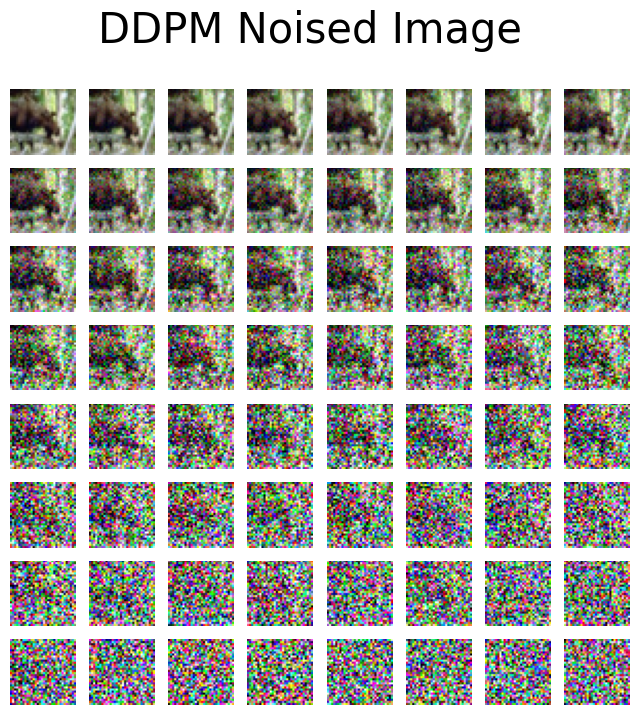

In [15]:
show_noise_image(ddpm=ddpm, dataloader=train_dataloader, device=device)

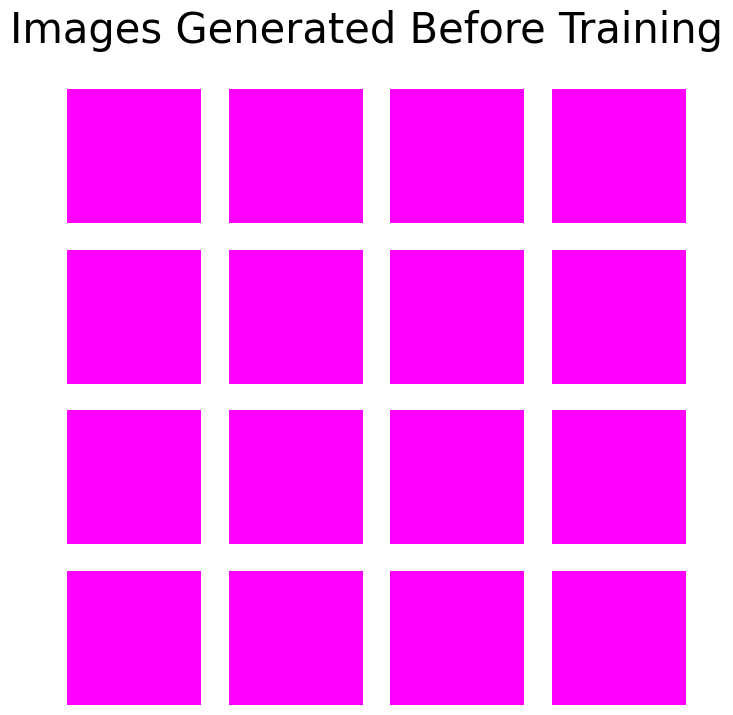

In [16]:
generated = generate_new_images(ddpm=ddpm)
show_images(generated, "Images Generated Before Training")

Every epoch, iterate through the dataloader and get a batch of images. Generate random noise with the shape of the images. Get a random index for timestep for each image in the batch. Perform the forward process of diffusion and get a noisy image. Get the model's estimation of noise based on the images and timesteps. Calculate the MSE loss between the model's estimation of noise and the actual noise applied to the image.

In [44]:
model_path = "cifar10_diffusion_model.pt"

if os.path.exists(model_path):
    print(f"Loading model from {model_path}...")
    ddpm.load_state_dict(torch.load(model_path, map_location=device))

train = True

Loading model from cifar10_diffusion_model.pt...


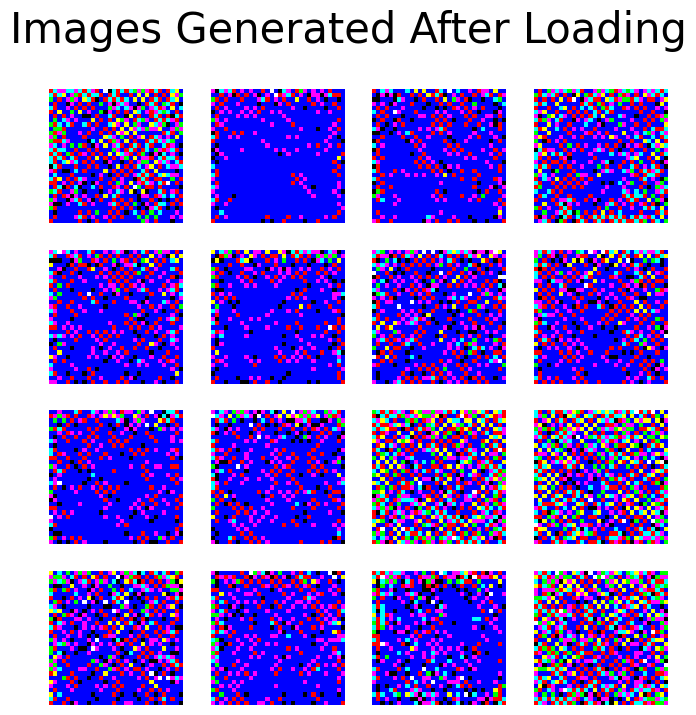

In [42]:
generated = generate_new_images(ddpm=ddpm)
show_images(generated, "Images Generated After Loading")

In [45]:
if train:
    pbar = trange(epochs, leave=False, desc="Epoch")
    ddpm.train()

    for epoch in pbar:
        mean_loss = 0

        pbar.set_postfix_str(f"Loss: {mean_loss / len(train_dataloader)}")

        for i, (images, labels) in enumerate(tqdm(train_dataloader, leave=False)):
            images = images.to(device)
            batch_size = images.shape[0]

            # Picking some noise for each of the images in the batch, a timestep and the respective alpha_bars
            latent_noise = torch.randn_like(images).to(device)

            # Get a random index
            rand_t = torch.randint(0, ddpm.timesteps, (batch_size,)).to(device)

            # Forward Process of Diffusion
            # Computing the noisy image based on X and the time-step
            noise_input = ddpm(images, rand_t, latent_noise)

            # Backward Process of Diffusion
            # Getting model estimation of noise based on the images and the timesteps
            noise_estimate = ddpm.backward(noise_input, rand_t)

            # Calculate the MSE loss between the model's estimation of noise and the actual noise applied to the image
            loss = loss_fn(noise_estimate, latent_noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mean_loss += loss.item()

        print(
            f"Epoch: {epoch + 1} | Loss: {mean_loss / len(train_dataloader)} --> Stored"
        )
        torch.save(ddpm.state_dict(), model_path)

Epoch:   0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

Epoch: 1 | Loss: 0.05846972501247513 --> Stored


  0%|          | 0/196 [00:00<?, ?it/s]

Epoch: 2 | Loss: 0.05852649828457102 --> Stored


...

Epoch: 378 | Loss: 0.05802525629346468 --> Stored


  0%|          | 0/196 [00:00<?, ?it/s]

Epoch: 379 | Loss: 0.057866170242124676 --> Stored


  0%|          | 0/196 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [46]:
ddpm.load_state_dict(torch.load(model_path, map_location=device))

ddpm.eval()
print("Model loaded")

Model loaded


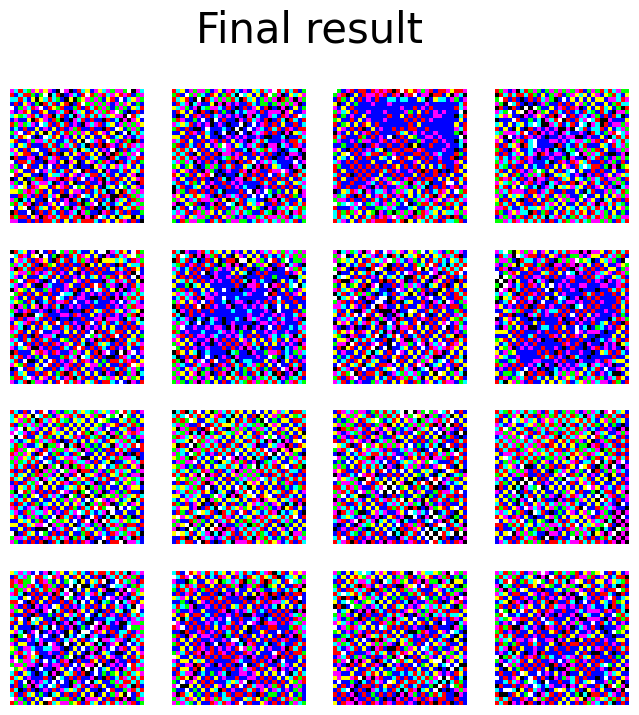

In [47]:
generated = generate_new_images(
    ddpm=ddpm,
    n_samples=16,
    device=device,
)
show_images(generated, "Final result")